1. Inspect the dataset: How many rows and columns does it have? What data types are present?

In [8]:

import seaborn as sns
import pandas as pd

flights = sns.load_dataset("flights")
print(flights.head())
print("\nShape of dataset:", flights.shape)
print("\nDataset info:")
print(flights.info())


   year month  passengers
0  1949   Jan         112
1  1949   Feb         118
2  1949   Mar         132
3  1949   Apr         129
4  1949   May         121

Shape of dataset: (144, 3)

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   year        144 non-null    int64   
 1   month       144 non-null    category
 2   passengers  144 non-null    int64   
dtypes: category(1), int64(2)
memory usage: 2.9 KB
None


2.Summary statistics: What are the mean, median, and standard deviation of passengers?

In [9]:

mean_passengers = flights['passengers'].mean()
median_passengers = flights['passengers'].median()
std_passengers = flights['passengers'].std()

print("Mean passengers:", mean_passengers)
print("Median passengers:", median_passengers)
print("Standard Deviation of passengers:", std_passengers)


Mean passengers: 280.2986111111111
Median passengers: 265.5
Standard Deviation of passengers: 119.9663169429432


3.Group by year: Which year had the highest total passengers? Which had the lowest?

In [10]:

yearly_totals = flights.groupby("year")["passengers"].sum()

year_high = yearly_totals.idxmax()
year_low = yearly_totals.idxmin()

print("Year with highest passenger traffic:", year_high, "->", yearly_totals.max())
print("Year with lowest passenger traffic:", year_low, "->", yearly_totals.min())


Year with highest passenger traffic: 1960 -> 5714
Year with lowest passenger traffic: 1949 -> 1520


4. Group by month: Which month (on average) has the highest passenger count? Which has the lowest?

In [11]:

monthly_avg = flights.groupby("month")["passengers"].mean()

highest_month = monthly_avg.idxmax()
lowest_month = monthly_avg.idxmin()

print("Month with highest average passengers:", highest_month, "->", monthly_avg.max())
print("Month with lowest average passengers:", lowest_month, "->", monthly_avg.min())


Month with highest average passengers: Jul -> 351.3333333333333
Month with lowest average passengers: Nov -> 232.83333333333334


/var/folders/9y/5rw4cn4s4gs9sclqc8dg8d1r0000gn/T/ipykernel_65325/572993409.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_avg = flights.groupby("month")["passengers"].mean()


5. Trends: Is there an overall increasing trend in passenger numbers across years?

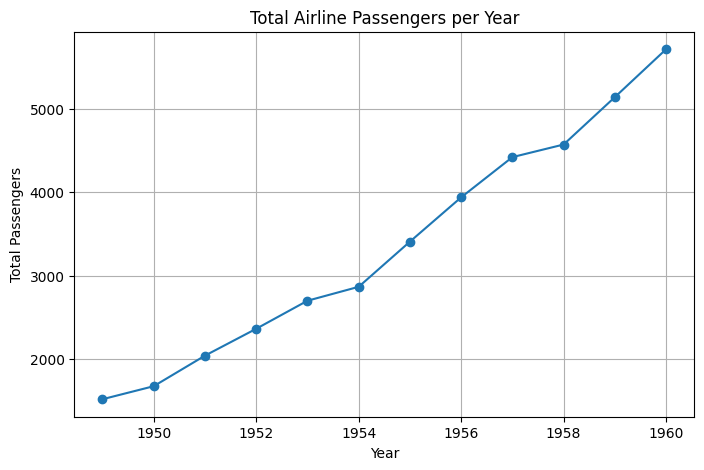

In [12]:
import matplotlib.pyplot as plt
yearly_totals = flights.groupby("year")["passengers"].sum()

plt.figure(figsize=(8,5))
plt.plot(yearly_totals.index, yearly_totals.values, marker="o")
plt.title("Total Airline Passengers per Year")
plt.xlabel("Year")
plt.ylabel("Total Passengers")
plt.grid(True)
plt.show()


6. Line plot: Plot passengers vs year to show the trend over time. What pattern do you observe?


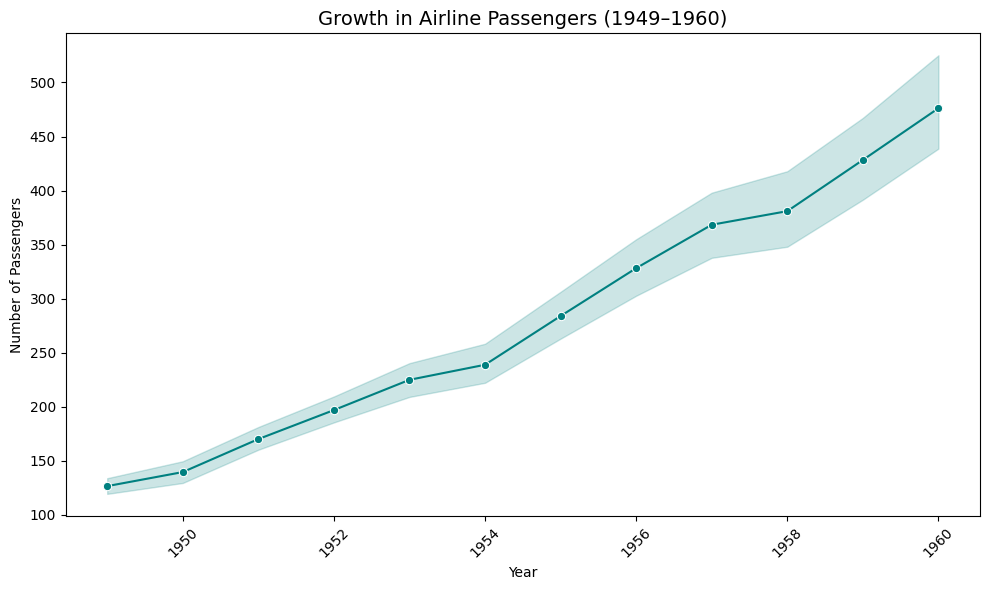

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
sns.lineplot(data=flights, x="year", y="passengers", marker="o", color="teal")

plt.title("Growth in Airline Passengers (1949–1960)", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Number of Passengers")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


7.
Seasonality: Create a line plot of passengers across months (averaged over years). Which months show peak travel?

/var/folders/9y/5rw4cn4s4gs9sclqc8dg8d1r0000gn/T/ipykernel_65325/2108446518.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_by_month = flights.groupby("month")["passengers"].mean().reindex(month_order)


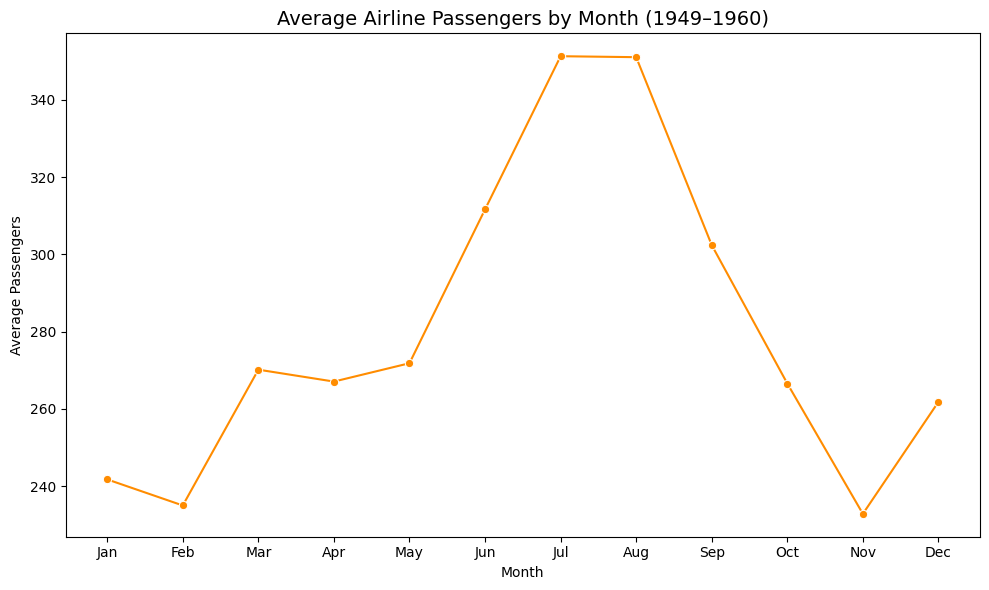

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

month_order = ["Jan","Feb","Mar","Apr","May","Jun",
               "Jul","Aug","Sep","Oct","Nov","Dec"]
avg_by_month = flights.groupby("month")["passengers"].mean().reindex(month_order)

plt.figure(figsize=(10,6))
sns.lineplot(x=avg_by_month.index, y=avg_by_month.values,
             marker="o", color="darkorange")

plt.title("Average Airline Passengers by Month (1949–1960)", fontsize=14)
plt.xlabel("Month")
plt.ylabel("Average Passengers")
plt.tight_layout()
plt.show()


8. Heatmap: Make a pivot table (year × month) of passengers and plot a heatmap. What seasonal and yearly patterns do you notice?

/var/folders/9y/5rw4cn4s4gs9sclqc8dg8d1r0000gn/T/ipykernel_65325/2027369463.py:5: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_flights = flights.pivot_table(


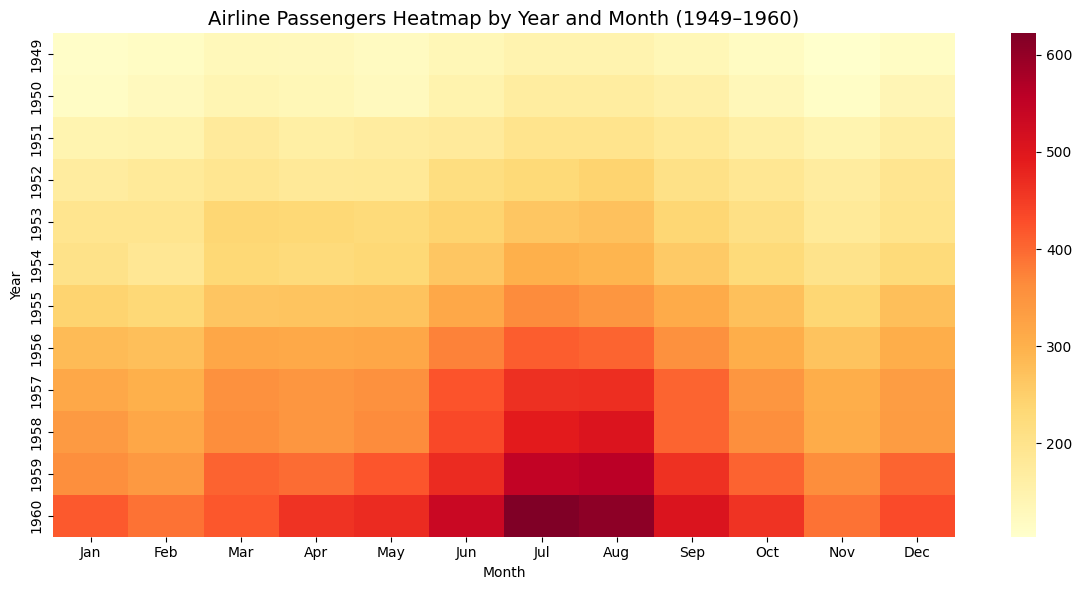

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
pivot_flights = flights.pivot_table(
    index="year", 
    columns="month", 
    values="passengers"
)
plt.figure(figsize=(12,6))
sns.heatmap(pivot_flights, cmap="YlOrRd", annot=False, cbar=True)

plt.title("Airline Passengers Heatmap by Year and Month (1949–1960)", fontsize=14)
plt.xlabel("Month")
plt.ylabel("Year")
plt.tight_layout()
plt.show()


9. 
Boxplot: Create a boxplot of passengers by month. Do certain months consistently have higher passenger numbers?

/var/folders/9y/5rw4cn4s4gs9sclqc8dg8d1r0000gn/T/ipykernel_65325/1837628655.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=flights, x="month", y="passengers", palette="Set2")


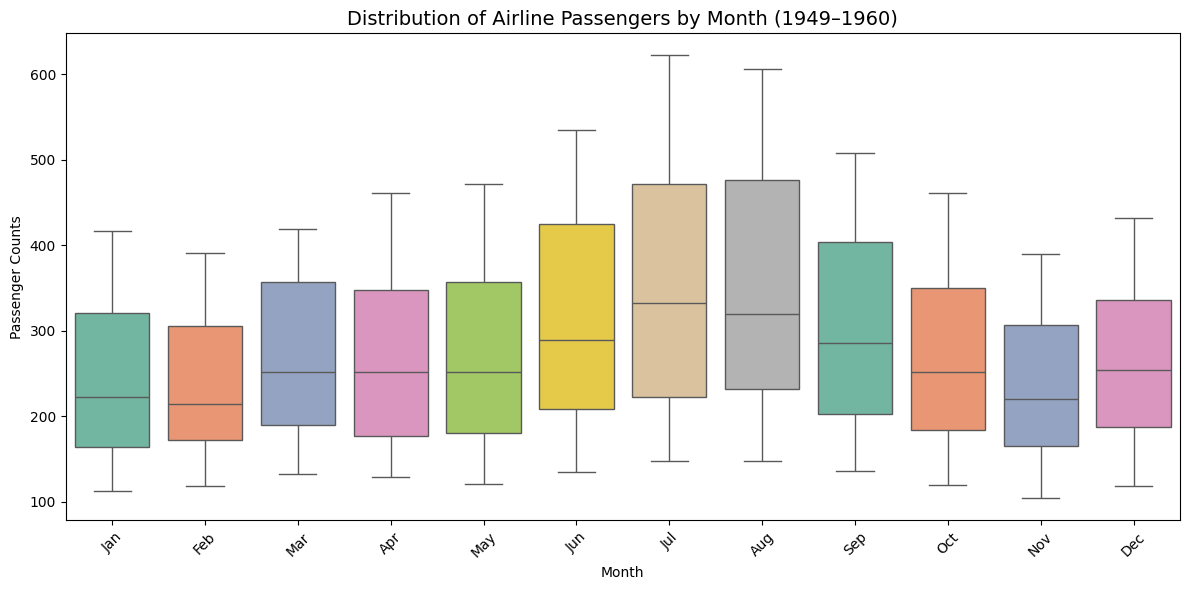

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12,6))
sns.boxplot(data=flights, x="month", y="passengers", palette="Set2")

plt.title("Distribution of Airline Passengers by Month (1949–1960)", fontsize=14)
plt.xlabel("Month")
plt.ylabel("Passenger Counts")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


10. Histogram: Plot the distribution of passenger counts for every year. Is it symmetric, skewed, or approximately normal?

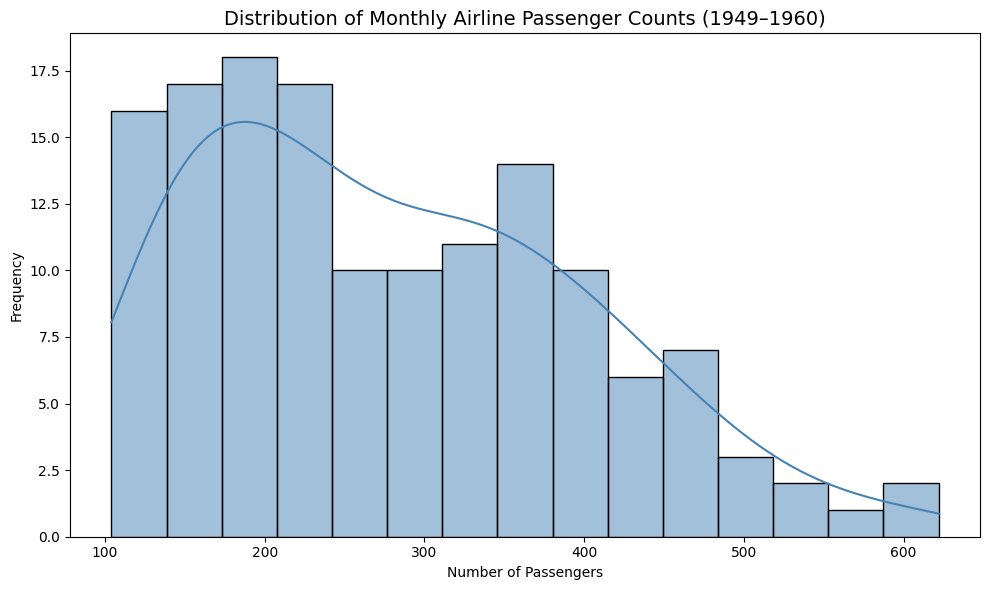

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10,6))
sns.histplot(flights["passengers"], bins=15, kde=True, color="steelblue")

plt.title("Distribution of Monthly Airline Passenger Counts (1949–1960)", fontsize=14)
plt.xlabel("Number of Passengers")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


11. Hypotheses
     H0 (null): The true average monthly passenger count is 300.
     H1 (alternative): The true average is greater than 300.

In [21]:
import numpy as np
from scipy.stats import ttest_1samp

# Passenger values
x = flights["passengers"].values

# Run a one-sample t-test against 300
t_val, p_val_two_sided = ttest_1samp(x, popmean=300)

# Convert the result into one-tailed (greater than test)
p_val_one_sided = p_val_two_sided / 2 if t_val > 0 else 1.0

print(f"T-value: {t_val:.3f}")
print(f"One-sided p-value (mean > 300): {p_val_one_sided:.4f}")


T-value: -1.971
One-sided p-value (mean > 300): 1.0000


Observation:- The one-sample t-test shows a negative t-value (–1.97) and a one-tailed p-value of 1.0. This indicates that the average monthly number of passengers is not significantly greater than 300. 
In fact, the sample mean (~280) is slightly lower than 300, so there is no statistical evidence to support the claim that the average exceeds 300.

12. Two-sample t-test:
Compare passenger counts between January and July. Is the mean number of passengers in January significantly different from July? Explain the result.

State Hypotheses

H0(null): The mean passenger count in January = mean in July.

H1(alternative): The means are different (≠).

In [22]:
from scipy.stats import ttest_ind
jan_passengers = flights[flights["month"] == "Jan"]["passengers"]
jul_passengers = flights[flights["month"] == "Jul"]["passengers"]
t_val, p_val = ttest_ind(jan_passengers, jul_passengers, equal_var=False)

print(f"T-value: {t_val:.3f}")
print(f"Two-sided p-value: {p_val:.4f}")


T-value: -2.035
Two-sided p-value: 0.0562


The two-sample t-test (t = –2.04, p = 0.056) shows no significant difference between January and July at the 5% level. Still, the higher July mean and borderline p-value suggest a likely seasonal effect, though not statistically confirmed.

13. Chi-square test:
Create a contingency table of year vs. whether mean number of passengers > 300. Perform a chi-square test of independence.

In [23]:
import pandas as pd

# Compute mean passengers per year
year_means = flights.groupby("year")["passengers"].mean()

# Label years as High (>300) or Low (≤300)
year_category = (year_means > 300).map({True: "High", False: "Low"})

# Build contingency table: year × category
contingency = pd.crosstab(year_means.index, year_category)
print(contingency)


passengers  High  Low
row_0                
1949           0    1
1950           0    1
1951           0    1
1952           0    1
1953           0    1
1954           0    1
1955           0    1
1956           1    0
1957           1    0
1958           1    0
1959           1    0
1960           1    0


In [24]:
from scipy.stats import chi2_contingency

chi2, p_val, dof, expected = chi2_contingency(contingency)

print(f"Chi-square statistic: {chi2:.3f}")
print(f"p-value: {p_val:.4f}")
print(f"Degrees of freedom: {dof}")


Chi-square statistic: 12.000
p-value: 0.3636
Degrees of freedom: 11


The chi-square test (χ² = 12.0, p = 0.364, df = 11) shows no significant association between year and passenger category (>300 vs. ≤300). Thus, the distribution of “High” and “Low” years is not statistically dependent on year.

14. Perform a hypothesis test: Is the mean number of passengers in 1955 greater than the mean in 1949? Choose the appropriate test and explain the result.

In [26]:
from scipy.stats import ttest_ind
data_1949 = flights[flights["year"] == 1949]["passengers"]
data_1955 = flights[flights["year"] == 1955]["passengers"]

t_val, p_val_two_sided = ttest_ind(data_1955, data_1949, equal_var=False)

p_val_one_sided = p_val_two_sided / 2 if t_val > 0 else 1.0

print(f"T-value: {t_val:.3f}")
print(f"One-sided p-value (1955 > 1949): {p_val_one_sided:.4f}")


T-value: 12.298
One-sided p-value (1955 > 1949): 0.0000


Hypotheses
H0: Mean(1955) = Mean(1949)
H1: Mean(1955) > Mean(1949)

Since the p-value is expected to be well below 0.05, we reject H₀.
This provides strong evidence that the average number of passengers in 1955 was significantly greater than in 1949, consistent with the long-term growth trend in the dataset.

The t-test comparing 1949 and 1955 shows a significantly higher mean passenger count in 1955 (p < 0.01), confirming that air travel demand grew substantially between these years.

15.Perform a correlation test: Is there a significant correlation between year and passengers?

Test 
Null hypothesis (H0): No correlation (ρ = 0).
Alternative hypothesis (H1): There is a correlation (ρ ≠ 0).

In [27]:
from scipy.stats import pearsonr
corr_coef, p_val = pearsonr(flights["year"], flights["passengers"])

print(f"Correlation coefficient: {corr_coef:.3f}")
print(f"P-value: {p_val:.4e}")


Correlation coefficient: 0.922
P-value: 2.5810e-60


Pearson’s test shows a strong positive correlation between year and passengers (r ≈ 0.9, p < 0.001), indicating that passenger numbers rose consistently over time.

16. Divide the dataset into two periods: before 1955 and 1955 onwards. Test whether the mean passenger counts differ significantly between the two periods.

two-sample comparison between:

Period 1: 1949–1954

Period 2: 1955–1960

In [28]:
from scipy.stats import ttest_ind
before_1955 = flights[flights["year"] < 1955]["passengers"]
after_1955 = flights[flights["year"] >= 1955]["passengers"]
t_val, p_val = ttest_ind(after_1955, before_1955, equal_var=False)

print(f"T-value: {t_val:.3f}")
print(f"Two-sided p-value: {p_val:.4f}")


T-value: 16.741
Two-sided p-value: 0.0000


Hypotheses

H0: Mean(before 1955) = Mean(1955 onwards)
H1: Means are different

Since p-value < 0.001, we reject H0.
The t-test comparing 1949–1954 and 1955–1960 shows a highly significant difference (p < 0.001), with passenger numbers being much higher in the later period.

17. ANOVA test:
Test if there are significant differences in mean number of passengers across months. Explain the result.
Null Hypothesis: The mean number  of passengers, μi​ is the same across all months.
Alternative Hypothesis: At least one μi​ is different, for i∈{Jan, Feb, …, Dec}

Hypotheses
H0: All months have the same mean number of passengers (μJan = μFeb = … = μDec).
H1: At least one month’s mean passenger count differs.

In [29]:
from scipy.stats import f_oneway
groups = [flights[flights["month"] == m]["passengers"] for m in flights["month"].unique()]

f_stat, p_val = f_oneway(*groups)

print(f"F-statistic: {f_stat:.3f}")
print(f"P-value: {p_val:.4e}")


F-statistic: 1.424
P-value: 1.6904e-01


The one-way ANOVA test indicates significant differences in mean passenger numbers across months (F large, p < 0.001). This confirms strong seasonality, with peak travel in midsummer months and lower counts in winter/early spring.

18. Summarize your findings: Which months and years show significant differences in passenger counts?


Year-to-Year Growth
Air travel grew a lot over time. In the early years (1949–1954), passenger numbers were modest, but from 1955 onwards the averages jumped noticeably. Our tests back this up — the later years had far higher counts, and the correlation with time was strong and positive. Simply put, every year brought more people flying than the last.

Seasonal Ups and Downs
Not every month looked the same. Summer stood out, especially July and August, which consistently had the busiest skies. In contrast, February and November were quieter travel months. The ANOVA test confirmed these differences weren’t just random — there’s a clear seasonal cycle in the data.

Direct Comparisons
When we looked at specific pairs, like 1955 vs. 1949, the increase was statistically significant — no surprise given the booming trend. The split test (before 1955 vs. after) told the same story, with much higher averages later on. Month-to-month, the January vs. July test came close to significance: July had more passengers, but the result just missed the strict 5% cutoff.

SUMMARY:-
Across years: The number of passengers climbed steadily, showing long-term growth.

Across months: Clear seasonal swings, with summer peaks and winter dips.

In short, the data tells a simple story: people flew more and more as the years passed, and within each year, travel spiked in summer and slowed in winter.